# 数值溢出（Numerical Overflow）与数值下溢（Numerical Underflow）。

它不像梯度爆炸那样有明确的"范数增长"信号，<font color='red'>而是悄无声息地在某个 exp() 或 log() 调用中触发</font>，然后像病毒一样污染整个计算图。

**下面我从浮点数机制、具体场景、数学原理、解决方案及工程实践五个层面系统拆解**。

## 浮点数的数值边界：<font color='red'>为什么 exp/log 是"高危函数"？</font>

### 1.1 FP32 与 FP16 的数值范围

在深度学习中，张量通常以 FP32（**单精度浮点**） 或 FP16（**半精度浮点**） 存储：


In [1]:
from IPython.display import Image

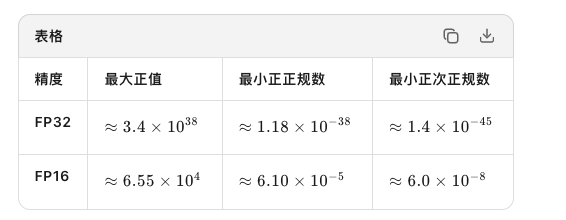

In [2]:
Image(filename='./Image/float.png')


**关键洞察：**
- <font color='red'>FP16 的动态范围极其狭窄！一个看似不大的数（如 $10^5$）在 FP16 中就会溢出为 inf</font>

### exp(x) 的"死亡线"
当 x >≈ <font color='red'>88.7</font> ,$e^x$在 FP32 中溢出为 ∞ 
   - 因为$ e^{88.7}$ ≈ 3.4×$10^{38}$ ，<font color='red'>刚好触及 FP32 上限</font>。
     - e（也称为欧拉数或自然常数）是一个无理数
     - e≈2.718281828459045...




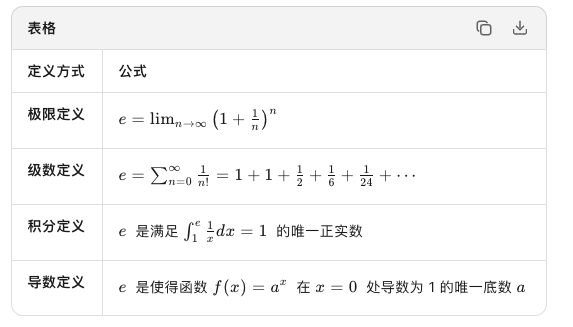

In [3]:
Image(filename='./Image/e.png')

### log(x) 的"死亡线"
- <font color='red'>x→$0^+$</font> ：<font color='blue'>log(x)→−∞ </font>，在 FP32 中当 x<≈$10^{−45}$时下溢为 −∞ ，进一步运算可能变成 NaN。
- <font color='red'>x=0</font> ：log(0)  在数学上无定义，在 PyTorch 中直接返回 -inf，若后续参与求平均、反向传播，会产生 NaN。
- <font color='red'> x<0 </font> ：log(负数)  直接返回 NaN。

#### 总结：在log中只要x无限接近0，=0，<0都会返回NaN

## 场景一：Softmax 的数值稳定性
### Softmax 的数学定义

$Softmax(x_i)  = \frac{e^{x_i}}{∑^N_{j=1}e^{x_j} }$

### 溢出的典型场景
假设 logits（未归一化的分数）为：
x=[1000,1001,999]

直接计算：
- $e^{1000}$ → ∞ （FP32 溢出）
- $e^{1001}$ → ∞ 
- <font color='red'>分子分母都是 inf，结果变成 NaN</font>

###  数值稳定技巧：减去最大值
核心洞察：<font color='blue'>Softmax 对输入的平移不变性</font>

$\frac{e^{x_i}}{∑_j{e^{x_j}}} = \frac{e^{x_i - C}}{∑_j{e^{x_j - C}}}$


取 **C = max_j(x_j)** ，则所有指数项 <font color='blue'> $e^{x_i − C} ≤ 1$ </font> ，彻底消除溢出风险:
 

In [ ]:
def stable_softmax(x):
    x_max = x.max(dim=-1, keepdim=True).values  # 减去最大值
    x_shifted = x - x_max
    exp_x = torch.exp(x_shifted)
    return exp_x / exp_x.sum(dim=-1, keepdim=True)

<font color='blue'>PyTorch 的 CrossEntropyLoss 内部已经做了这个优化，所以直接使用官方 API 通常是安全的。</font>
- **但如果你自定义 loss（如知识蒸馏中的软标签交叉熵、对比学习中的 InfoNCE），必须手动处理。**


## 场景二：log(0) 与 log(极小值)

###  问题来源
在自定义损失函数中，常见模式：
  - 计算交叉熵：$L=−∑y_ilog(p_i) $
    - 若模型对某个类别极度自信，$p_i$→0 （对于真实标签以外的类别）
    - $p_i$ → 1 （对于真实标签）
  - <font color='red'>若因数值精度问题 $p_i$被截断为精确的 0，则 log(0)=−∞ </font>
  - 若损失是 NaN 或 -inf，反向传播直接崩溃
  
###  解决方案对比
图片中给出了两种方案，各有优劣：

| 方案               | 代码                         | 原理                      | 优缺点                                        |
| ---------------- | -------------------------- | ----------------------- | ------------------------------------------ |
| **Clamp 限幅**     | `torch.clamp(x, min=1e-8)` | 将概率强制截断到 $[10^{-8}, 1]$ | 简单直接；但**硬截断**会改变梯度，在 $x < 10^{-8}$ 区域梯度为 0 |
| **加 epsilon 平滑** | `torch.log(x + 1e-8)`      | 给输入加极小值，避免精确为 0         | 更平滑，梯度始终非零；但略微改变损失函数的理论值                   |
#### 推荐实践：

In [ ]:
# 方法1：加 epsilon（更平滑，推荐）
eps = 1e-8
log_prob = torch.log(prob + eps)

# 方法2：clamp（若需要严格保证概率在有效范围内）
prob_safe = torch.clamp(prob, min=eps, max=1.0)
log_prob = torch.log(prob_safe)

注意：<font color='red'>CrossEntropyLoss 内部使用 log_softmax 的数值稳定实现，通常不需要手动加 eps。自定义 loss 时才需要</font>

## 场景三：exp(x) 中 x 过大
### 问题来源
除 Softmax 外，<font color='red'>exp() 在以下场景也极易溢出：</font>
- 注意力机制：QK^T / \sqrt{d_k}若未做温度缩放或输入未归一化，内积可能极大
- 高斯核 / RBF：e^{−∣∣x−y∣∣ / σ^2}的分母若过小
- 强化学习中的优势函数：某些算法（如 A2C）中<font color='red'>优势估计涉及指数化</font>
- 对比学习 / InfoNCE：温度系数 τ  过小，x/τ  变得极大

### 解决方案：torch.clamp(x, max=80)
图片建议将输入 clamp 到 80，这背后的数学：
$e^{80} ≈ 5.5×10^{34}$
 
这个值：
- 远小于 FP32 上限 3.4×10^{38}，安全
- 但又足够大，保留了 exp 的区分度（$e^{80}$与 $e^{70}$仍相差 $10^4$量级）

代码实践：

In [ ]:
# 在 exp 前限制输入
x_clamped = torch.clamp(x, max=80.0)
exp_x = torch.exp(x_clamped)

#### 更优雅的替代：<font color='red'>使用 torch.exp 的数值稳定变体</font>
在某些算法中（如 Log-Sum-Exp），直接用 <font color='red'>torch.logsumexp</font> 代替手动 exp + log：

In [ ]:
# 不稳定的写法
loss = torch.log(torch.exp(x).sum())

# 稳定的写法
loss = torch.logsumexp(x, dim=-1)

<font color='red'>torch.logsumexp 内部自动做了减去最大值的稳定处理</font>

## 综合诊断流程
当你在训练日志中看到 NaN 或 inf，且已排除梯度爆炸和学习率问题后，按以下流程排查数值溢出：

In [ ]:
def check_numerical_health(model, loss):
    issues = []
    
    # 1. 检查损失本身
    if torch.isnan(loss) or torch.isinf(loss):
        issues.append(f"Loss is {loss.item()}")
    
    # 2. 检查各层激活值
    for name, param in model.named_parameters():
        if param is not None:
            if torch.isnan(param).any():
                issues.append(f"NaN in param: {name}")
            if torch.isinf(param).any():
                issues.append(f"Inf in param: {name}")
    
    # 3. 检查中间激活（需在前向传播时 hook）
    # ...
    
    return issues

## 工程最佳实践总结

| 场景                         | 危险操作                           | 安全做法                                                     |
| -------------------------- | ------------------------------ | -------------------------------------------------------- |
| **Softmax / CrossEntropy** | 手动 `exp / sum(exp)`            | 用 `F.softmax` 或 `F.cross_entropy`（<font color='red'>内部已稳定化</font>）                |
| **自定义交叉熵**                 | `torch.log(prob)` 当 prob 可能为 0 | `torch.log(prob + 1e-8)` 或 `torch.clamp(prob, min=1e-8)` |
| **任意 exp()**               | 直接 `torch.exp(x)` 当 x 无界       | `torch.exp(torch.clamp(x, max=80))` 或算法层面限制 x 的范围        |
| **混合精度训练**                 | 在 FP16 中随意使用 exp               | 关键计算保留 FP32；或用 `torch.cuda.amp` 的 `autocast` 自动管理        |
| **对比学习 / InfoNCE**         | $x/\tau$ 中温度 $\tau$ 过小         | 设置 $\tau \geq 0.05$；或使用 `logsumexp`                      |

## 一句话总结

数值溢出是浮点数有限精度与数学函数无限定义域之间的根本矛盾：
- $e^{88}$在数学上完美存在，在 FP32 中却已是地狱。
- Softmax 靠"减最大值"偷天换日，
- log(0) 靠"加 epsilon"瞒天过海，
- exp(x) 靠"clamp 限幅"画地为牢
**这些不是 trick，而是深度学习工程师在数值废墟上建立的生存法则。**